# Daily Challenge: Analyzing the IMDB Movie Dataset with Matplotlib and Seaborn

## Load & Inspect Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('imdb_top_1000.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData types:\n', df.dtypes)
df.head()

Shape: (1000, 16)

Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']

Data types:
 Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


## Data Preprocessing

In [2]:
# Check missing values
print('Missing values:\n', df.isnull().sum())

# Convert Released_Year to numeric (some entries may be strings)
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Convert Gross to numeric (remove commas)
df['Gross'] = df['Gross'].astype(str).str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')

# Convert Runtime to numeric (remove ' min')
df['Runtime'] = df['Runtime'].astype(str).str.replace(' min', '', regex=False)
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

# Drop rows missing key columns
df = df.dropna(subset=['IMDB_Rating', 'Released_Year'])

print('\nCleaned shape:', df.shape)

Missing values:
 Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

Cleaned shape: (999, 16)


## IMDB Rating Trends Over Years

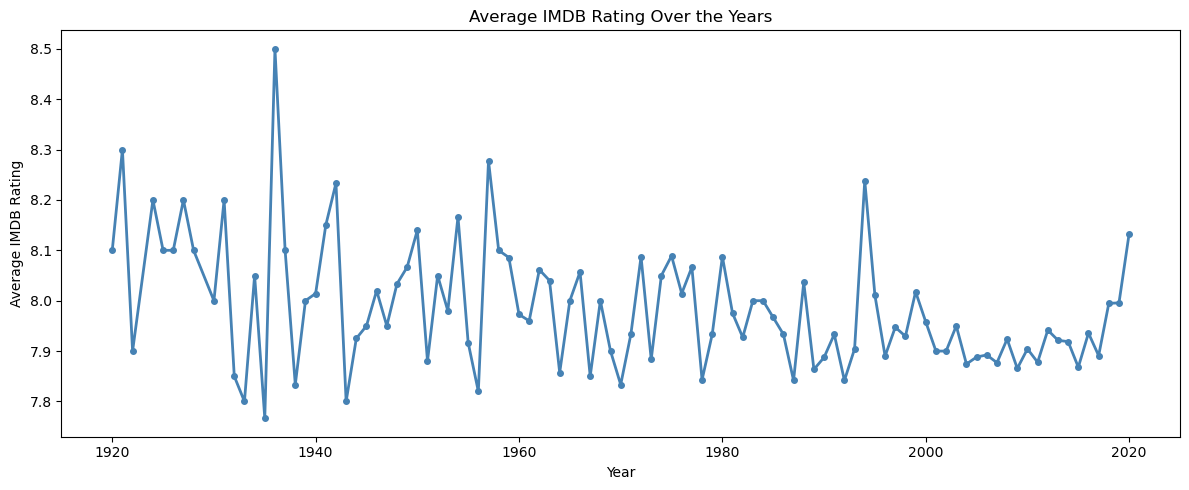

In [3]:
yearly = df.groupby('Released_Year')['IMDB_Rating'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Released_Year'], yearly['IMDB_Rating'], color='steelblue', linewidth=2, marker='o', markersize=4)

plt.title('Average IMDB Rating Over the Years')
plt.xlabel('Year')
plt.ylabel('Average IMDB Rating')
plt.tight_layout()
plt.show()

## Genre Popularity Analysis

C:\Users\hp\AppData\Local\Temp\ipykernel_32660\434025807.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_counts, x='Genre', y='Count', palette='viridis')


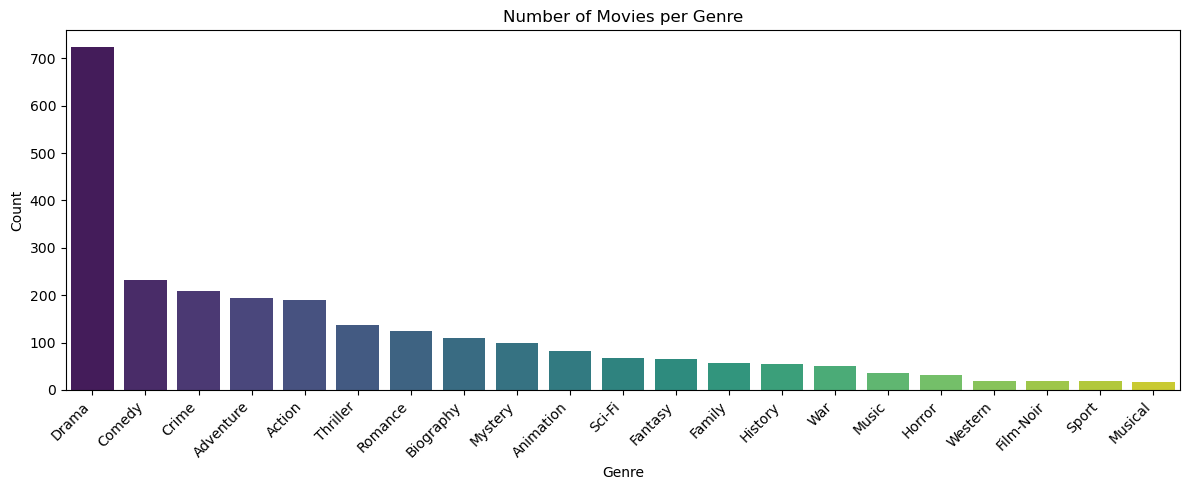

In [4]:
# Each movie can have multiple genres — split and explode
genre_series = df['Genre'].dropna().str.split(', ').explode()
genre_counts = genre_series.value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

plt.figure(figsize=(12, 5))
sns.barplot(data=genre_counts, x='Genre', y='Count', palette='viridis')

plt.title('Number of Movies per Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Director's Impact on Ratings

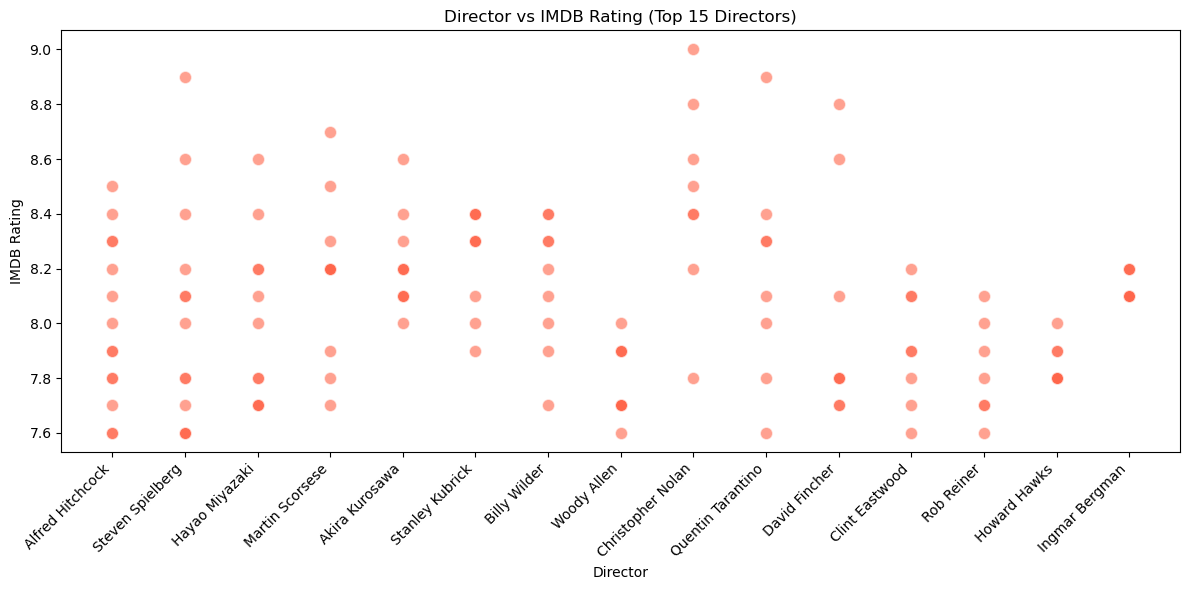

In [5]:
# Keep top 15 directors by movie count for readability
top_directors = df['Director'].value_counts().head(15).index
df_dir = df[df['Director'].isin(top_directors)]

# Assign a numeric index per director for x-axis
director_map = {d: i for i, d in enumerate(top_directors)}
df_dir = df_dir.copy()
df_dir['Dir_idx'] = df_dir['Director'].map(director_map)

plt.figure(figsize=(12, 6))
plt.scatter(df_dir['Dir_idx'], df_dir['IMDB_Rating'], alpha=0.6, color='tomato', edgecolors='white', s=80)

plt.xticks(ticks=list(director_map.values()), labels=list(director_map.keys()), rotation=45, ha='right')
plt.title('Director vs IMDB Rating (Top 15 Directors)')
plt.xlabel('Director')
plt.ylabel('IMDB Rating')
plt.tight_layout()
plt.show()

## Star Power Analysis (Pairplot)

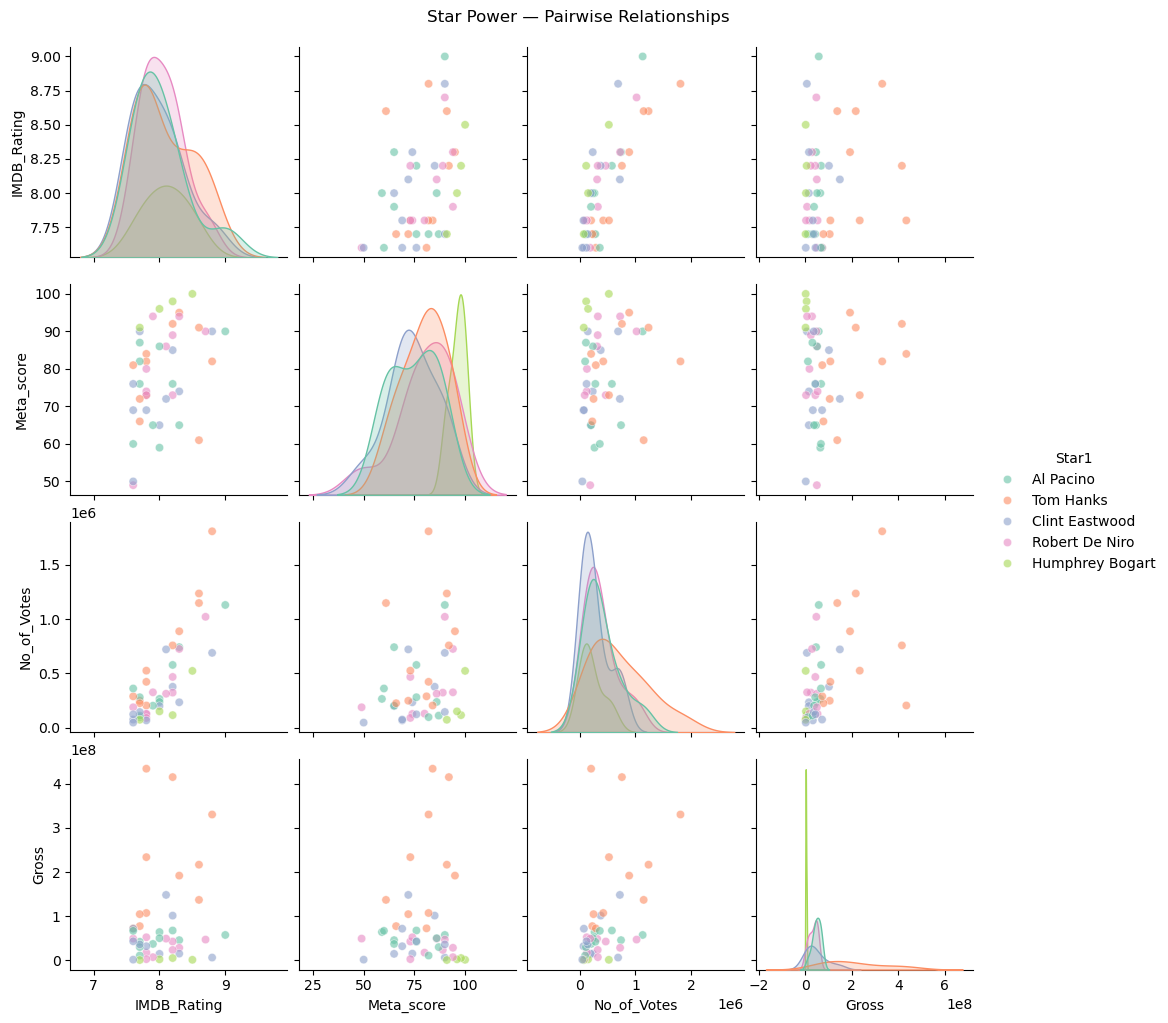

In [6]:
# Use Star1 as a categorical hue; keep numeric columns
# Pick top 5 stars for readability
top_stars = df['Star1'].value_counts().head(5).index
df_stars = df[df['Star1'].isin(top_stars)][['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Star1']].dropna()

sns.pairplot(df_stars, hue='Star1', palette='Set2', plot_kws={'alpha': 0.6})
plt.suptitle('Star Power — Pairwise Relationships', y=1.02)
plt.show()

## Box Plot: Genre vs IMDB Rating

C:\Users\hp\AppData\Local\Temp\ipykernel_32660\3165872554.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_genre, x='Genre', y='IMDB_Rating', palette='Set3')


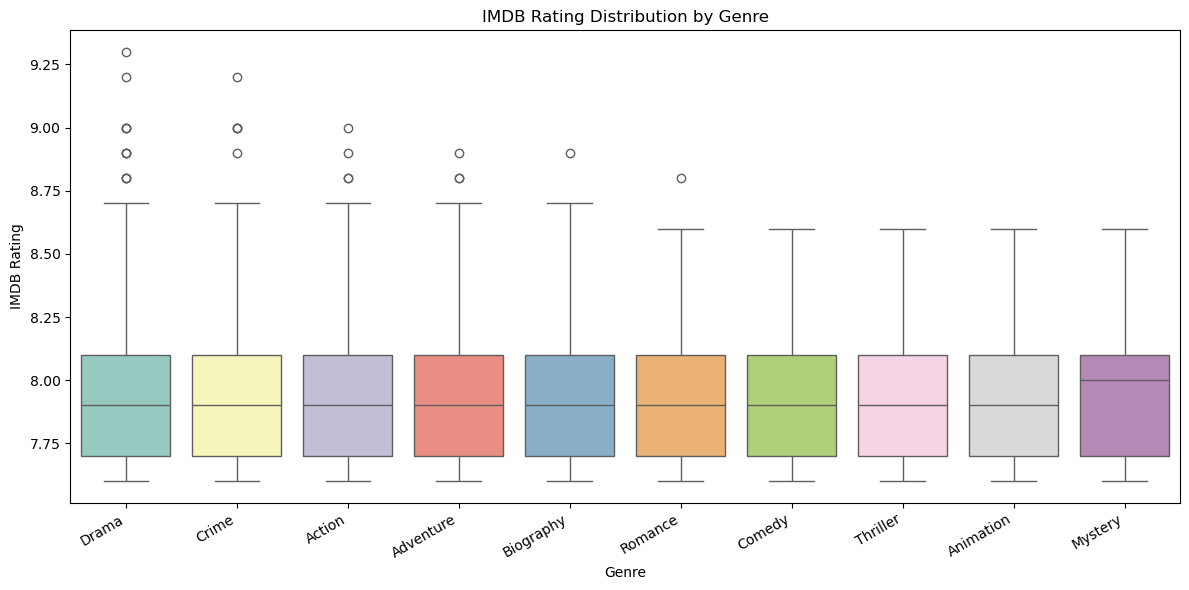

In [7]:
# Explode genres and merge back ratings
df_genre = df[['Genre', 'IMDB_Rating']].dropna().copy()
df_genre['Genre'] = df_genre['Genre'].str.split(', ')
df_genre = df_genre.explode('Genre')

# Keep top 10 genres
top_genres = df_genre['Genre'].value_counts().head(10).index
df_genre = df_genre[df_genre['Genre'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_genre, x='Genre', y='IMDB_Rating', palette='Set3')

plt.title('IMDB Rating Distribution by Genre')
plt.xlabel('Genre')
plt.ylabel('IMDB Rating')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Correlation Heatmap

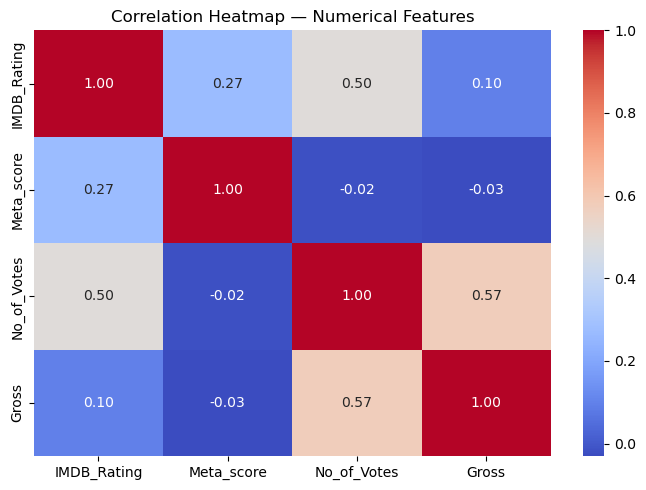

In [8]:
# Note: column name may be 'No_of_Votes' or 'No_of_votes' depending on the file
num_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']

# Use whichever spelling exists
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()